In [1]:
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
import lightgbm as lgb

import matplotlib.pyplot as plt 
from matplotlib.backends.backend_pdf import PdfPages 
%matplotlib inline 

### 1. import data

In [2]:
train = pd.read_csv('train_data.csv')
test = pd.read_csv('test_data.csv')
val = pd.read_csv('val_data.csv')
c1 = ['Gender', 'Married', 'Age', 'CreditScore', 'Dependents', 'NumBankAccts', 'HasCrCard', 'EmergingMarketFund', 'RealEstate',
      'PrivateEquity', 'GovtBonds', 'CorpBonds', 'ETF Tech', 'ETF Health', 'ETF Med', 'Debt', 'Net Assets', 'Mortgage', 
      'EstimatedSalary', 'Portfolio Return', 'Diversification', 'BusinessOwner', 'Revenue', 'LifeInsurance', 
      'NumTransactions', 'DaysSinceLastTransaction', 'ForeignAssets', 'NumProducts']
c2 = [0, 0, -1, -1, -1, -1, -1, -1, -1,
      -1, -1, -1, -1, -1, -1, 1, -1, -1,
      0, -1, -1, -1, -1, -1, 
      -1, 1, -1, -1]

### 2. D Tree

In [3]:
train_dtree = train.copy()
train_dtree['Gender'] = np.where(train_dtree['Gender']=='Male',1,np.where(train_dtree['Gender']=='Female',0,np.nan))
test_dtree = test.copy()
test_dtree['Gender'] = np.where(test_dtree['Gender']=='Male',1,np.where(test_dtree['Gender']=='Female',0,np.nan))

for i in train_dtree.columns[1:-1]:
    j = np.round(np.mean(train_dtree[i]),0)
    train_dtree[i] = train_dtree[i].fillna(j)
    test_dtree[i] = test_dtree[i].fillna(j)

md1 = []
ms1 = []
ar1 = []
ar2 = []
for md2 in [2,5,10,20]:
    for ms2 in [50,100,200,500]:
        md1.append(md2)
        ms1.append(ms2)
        x = train_dtree.drop(['CustomerID', 'Churn'], axis=1)
        y = train_dtree[['Churn']]
        
        model = DecisionTreeClassifier(criterion='gini', max_depth=md2, min_samples_leaf=ms2, random_state=42, monotonic_cst=c2)
        model.fit(x, y)
        p = model.predict_proba(x)[:, 1]
        ar1.append(roc_auc_score(y, p))
        
        x = test_dtree.drop(['CustomerID', 'Churn'], axis=1)
        y = test_dtree[['Churn']]
        p = model.predict_proba(x)[:, 1]
        ar2.append(roc_auc_score(y, p))
        
gb = pd.DataFrame({'max_depth':md1, 'min_samples_leaf':ms1, 'train_auroc':ar1, 'test_auroc':ar2})
gb = gb.sort_values('test_auroc', ascending=False)
gb.head(15)

,max_depth,min_samples_leaf,train_auroc,test_auroc
6,5,200,0.544974,0.490892
10,10,200,0.546999,0.490734
14,20,200,0.546999,0.490734
9,10,100,0.558177,0.488931
13,20,100,0.558177,0.488931
2,2,200,0.528786,0.487482
3,2,500,0.528786,0.487482
0,2,50,0.526060,0.487016
1,2,100,0.526060,0.487016
8,10,50,0.564039,0.486150


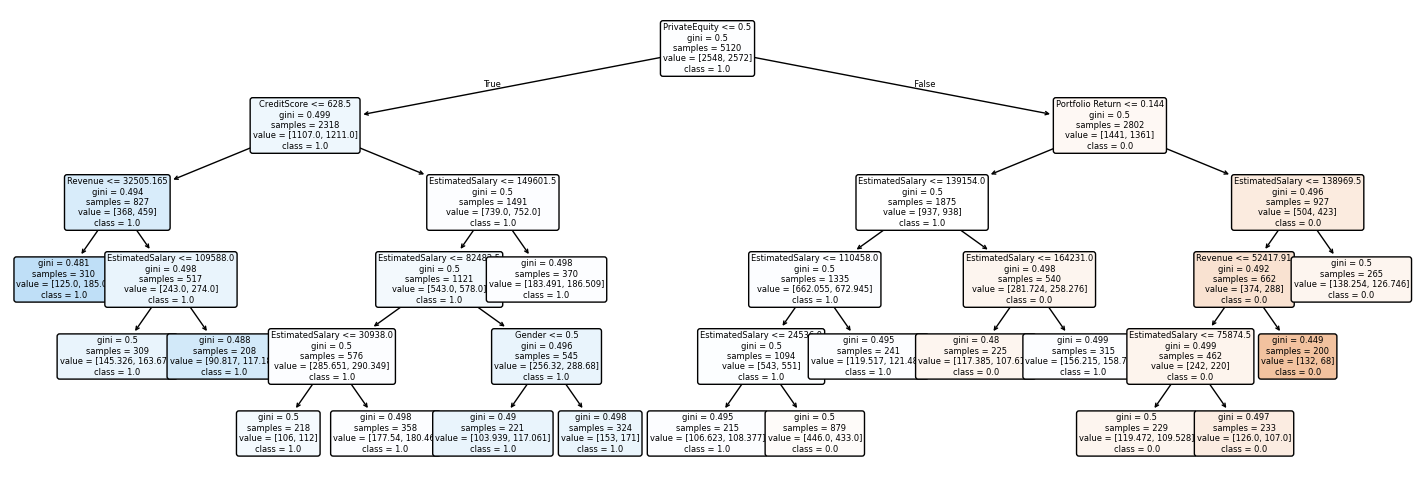

In [4]:
x = train_dtree.drop(['CustomerID', 'Churn'], axis=1)
y = train_dtree[['Churn']]
model = DecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_leaf=200, random_state=42, monotonic_cst=c2)
model.fit(x, y)

plt.figure(figsize=(18, 6))
plot_tree(model, filled=True, feature_names=x.columns, class_names=[str(i) for i in model.classes_], rounded=True, fontsize=6);
plt.show()

In [5]:
train_dtree = train.copy()
train_dtree['Gender'] = np.where(train_dtree['Gender']=='Male',1,np.where(train_dtree['Gender']=='Female',0,np.nan))
test_dtree = test.copy()
test_dtree['Gender'] = np.where(test_dtree['Gender']=='Male',1,np.where(test_dtree['Gender']=='Female',0,np.nan))
val_dtree = val.copy()
val_dtree['Gender'] = np.where(val_dtree['Gender']=='Male',1,np.where(val_dtree['Gender']=='Female',0,np.nan))

for i in train_dtree.columns[1:-1]:
    j = np.round(np.mean(train_dtree[i]),0)
    train_dtree[i] = train_dtree[i].fillna(j)
    test_dtree[i] = test_dtree[i].fillna(j)
    val_dtree[i] = val_dtree[i].fillna(j)

x = train_dtree.drop(['CustomerID', 'Churn'], axis=1)
y = train_dtree[['Churn']]
model = DecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_leaf=200, random_state=42, monotonic_cst=c2)
model.fit(x, y)
p = model.predict_proba(x)[:, 1]
print('train shape',train_dtree.shape,'\t\t train avg chrun rate',np.round(np.mean(train_dtree['Churn'])*100,1),'\t\t train auroc',np.round(roc_auc_score(y, p),3)) 
        
x = test_dtree.drop(['CustomerID', 'Churn'], axis=1)
y = test_dtree[['Churn']]
p = model.predict_proba(x)[:, 1]
print('test shape',test_dtree.shape,'\t\t test avg chrun rate',np.round(np.mean(test_dtree['Churn'])*100,1),'\t\t test auroc',np.round(roc_auc_score(y, p),3)) 

x = val_dtree.drop(['CustomerID', 'Churn'], axis=1)
y = val_dtree[['Churn']]
p = model.predict_proba(x)[:, 1]
print('val shape',val_dtree.shape,'\t\t val avg chrun rate',np.round(np.mean(val_dtree['Churn'])*100,1),'\t\t val auroc',np.round(roc_auc_score(y, p),3)) 

train shape (5120, 30) 		 train avg chrun rate 50.2 		 train auroc 0.545
test shape (2462, 30) 		 test avg chrun rate 49.4 		 test auroc 0.491
val shape (2418, 30) 		 val avg chrun rate 49.0 		 val auroc 0.501


### 3. Light GBM

In [6]:
train_lgb = train.copy()
train_lgb['Gender'] = train_lgb['Gender'].astype('category')
test_lgb = test.copy()
test_lgb['Gender'] = test_lgb['Gender'].astype('category')

md1 = []
ms1 = []
ar1 = []
ar2 = []
for md2 in [10,20,50]:
    for ms2 in [20,50,100]:
        md1.append(md2)
        ms1.append(ms2)
        x = train_lgb.drop(['CustomerID', 'Churn'], axis=1)
        y = train_lgb[['Churn']]
        train_set = lgb.Dataset(x, label=y, categorical_feature=['Gender'], free_raw_data=False)
        
        params = {'objective': 'binary', 'metric': 'auc', 'max_depth': md2, 'min_data_in_leaf': ms2,
                    'monotone_constraints': c2, 'monotone_constraints_method': 'advanced', 
                    'verbosity': -1, 'seed': 42}
        model = lgb.train(params, train_set, num_boost_round=1)  
        p = model.predict(x)
        ar1.append(roc_auc_score(y, p))
    
        x = test_lgb.drop(['CustomerID', 'Churn'], axis=1)
        y = test_lgb[['Churn']]
        p = model.predict(x)
        ar2.append(roc_auc_score(y, p))
    
gb = pd.DataFrame({'max_depth':md1, 'min_data_in_leaf':ms1, 'train_auroc':ar1, 'test_auroc':ar2})
gb = gb.sort_values('test_auroc', ascending=False)
gb.head(15)

,max_depth,min_data_in_leaf,train_auroc,test_auroc
4,20,50,0.562075,0.508412
7,50,50,0.562075,0.508412
1,10,50,0.559374,0.507140
0,10,20,0.561638,0.497262
3,20,20,0.562623,0.496105
6,50,20,0.562623,0.496105
2,10,100,0.554118,0.483914
5,20,100,0.554118,0.483914
8,50,100,0.554118,0.483914


In [7]:
x = train_lgb.drop(['CustomerID', 'Churn'], axis=1)
y = train_lgb[['Churn']]
params = {'objective': 'binary', 'metric': 'auc', 'max_depth': 20, 'min_data_in_leaf': 50,
            'monotone_constraints': c2, 'monotone_constraints_method': 'advanced', 
            'verbosity': -1, 'seed': 42}
model = lgb.train(params, train_set, num_boost_round=1)  
tree_struct = model.dump_model()['tree_info'][0]['tree_structure']

def fmt_threshold(thr):
    if thr is None:
        return "None"
    if abs(thr) > 1e15:  
        return "inf" if thr > 0 else "-inf"
    return f"{thr:.2f}"  

def print_tree(node, depth=0):
    indent = "  " * depth
    if 'leaf_value' in node:
        print(f"{indent}-> leaf: value = {node['leaf_value']:.4f}, count = {node.get('leaf_count', 'NA')}")
        return
    feat_name = c1[node['split_feature']]
    default_left = node['default_left']
    if node['decision_type'] == '==':
        print(f"{indent}if {feat_name} in {node.get('cat_threshold')} (missing -> {'left' if default_left else 'right'}):")
    else:
        thr = fmt_threshold(node['threshold'])
        print(f"{indent}if {feat_name} <= {thr} (missing -> {'left' if default_left else 'right'}):")
    print_tree(node['left_child'], depth + 1)
    print(f"{indent}else:")
    print_tree(node['right_child'], depth + 1)

print_tree(tree_struct)

if PrivateEquity <= 0.00 (missing -> right):
  if Diversification <= 0.34 (missing -> left):
    if DaysSinceLastTransaction <= 120.00 (missing -> left):
      -> leaf: value = 0.0041, count = 103
    else:
      if CreditScore <= 773.50 (missing -> left):
        if EstimatedSalary <= 56961.00 (missing -> right):
          if Net Assets <= 26726.00 (missing -> left):
            -> leaf: value = 0.0993, count = 55
          else:
            if Portfolio Return <= 0.11 (missing -> left):
              if Debt <= 22447.50 (missing -> right):
                -> leaf: value = 0.0280, count = 51
              else:
                -> leaf: value = 0.0594, count = 51
            else:
              -> leaf: value = 0.0041, count = 199
        else:
          if Revenue <= inf (missing -> right):
            if Diversification <= 0.00 (missing -> left):
              -> leaf: value = 0.1023, count = 98
            else:
              if EstimatedSalary <= 157346.00 (missing -> left):
      

In [8]:
train_lgb = train.copy()
train_lgb['Gender'] = train_lgb['Gender'].astype('category')
test_lgb = test.copy()
test_lgb['Gender'] = test_lgb['Gender'].astype('category')
val_lgb = val.copy()
val_lgb['Gender'] = val_lgb['Gender'].astype('category')

x = train_lgb.drop(['CustomerID', 'Churn'], axis=1)
y = train_lgb[['Churn']]
params = {'objective': 'binary', 'metric': 'auc', 'max_depth': 20, 'min_data_in_leaf': 50,
            'monotone_constraints': c2, 'monotone_constraints_method': 'advanced', 
            'verbosity': -1, 'seed': 42}
model = lgb.train(params, train_set, num_boost_round=1)  
p = model.predict(x)
print('train shape',train_lgb.shape,'\t\t train avg chrun rate',np.round(np.mean(train_lgb['Churn'])*100,1),'\t\t train auroc',np.round(roc_auc_score(y, p),3)) 
        
x = test_lgb.drop(['CustomerID', 'Churn'], axis=1)
y = test_lgb[['Churn']]
p = model.predict(x)
print('test shape',test_lgb.shape,'\t\t test avg chrun rate',np.round(np.mean(test_lgb['Churn'])*100,1),'\t\t test auroc',np.round(roc_auc_score(y, p),3)) 

x = val_lgb.drop(['CustomerID', 'Churn'], axis=1)
y = val_lgb[['Churn']]
p = model.predict(x)
print('val shape',val_lgb.shape,'\t\t val avg chrun rate',np.round(np.mean(val_lgb['Churn'])*100,1),'\t\t val auroc',np.round(roc_auc_score(y, p),3)) 

train shape (5120, 30) 		 train avg chrun rate 50.2 		 train auroc 0.562
test shape (2462, 30) 		 test avg chrun rate 49.4 		 test auroc 0.508
val shape (2418, 30) 		 val avg chrun rate 49.0 		 val auroc 0.505
